# **Lab 04.2 - Policy-Based Reinforcement Learning for Edge Offloading**


##### Copyright by UIT-NC@NT549

## **Some instructions before getting started**:
<div style="font-family: 'Arial'; font-size: 16px; line-height: 1.6; text-align: justify;">

Start the Kernel: At the top right, choose <strong>Select Kernel ➞ Python Environments...</strong>

You can run all code blocks to check: From the menu bar, choose <strong>Run All</strong>.

Complete all code blocks marked with the comment <span style="font-family: monospace; font-weight: bold; color:white; background-color: green;"> ### YOU NEED TO WRITE YOUR CODE BELOW ### </span>

This lab consists of 7 practical sections:
<ol style="margin-left: 20px;">
  <li><strong>Part 1: Build EdgeOffloadingEnv and Validate Environment Behavior</strong> (2-layer system: device and edge, check_env and short rollout))</li>
  <li><strong>Part 2: Baseline Policies</strong> (random, device-only, edge-only, greedy)</li>
  <li><strong>Part 3: REINFORCE</strong> (from scratch)</li>
  <li><strong>Part 4: Actor-Critic</strong> (from scratch)</li>
  <li><strong>Part 5: A2C</strong> (Stable-Baselines3)</li>
  <li><strong>Part 6: Final Comparison + Reflection</strong></li>
</ol>
</div>

In [134]:
# ============================================================================
# Imports and runtime stability config
# ============================================================================

import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gymnasium as gym
from gymnasium import spaces
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.distributions import Categorical

# Limit PyTorch threading for kernel stability on macOS
torch.set_num_threads(1)
try:
    torch.set_num_interop_threads(1)
except RuntimeError:
    pass

# Reproducibility
SEED = 42
FAST_MODE = True
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Device info
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print(f'PyTorch: {torch.__version__}')
print(f'NumPy: {np.__version__}')
print(f'Gymnasium: {gym.__version__}')
print(f'FAST_MODE: {FAST_MODE}')

# Shared plotting helpers
plt.rcParams.update({
    'figure.figsize': (10, 4),
    'axes.grid': True,
    'grid.alpha': 0.25,
})

def moving_average(values, window=20):
    """Smooth a learning curve using a moving average."""
    if len(values) == 0:
        return np.array([])
    return pd.Series(values).rolling(window=window, min_periods=1).mean().to_numpy()


def plot_curve(values, title, ylabel, window=20):
    """Plot raw values together with a moving average."""
    x = np.arange(1, len(values) + 1)
    plt.figure(figsize=(10, 4))
    plt.plot(x, values, alpha=0.35, label='Episode value')
    plt.plot(x, moving_average(values, window), lw=2, label=f'{window}-episode moving average')
    plt.title(title)
    plt.xlabel('Episode')
    plt.ylabel(ylabel)
    plt.legend()
    plt.tight_layout()
    plt.show()


def evaluate_edge_policy(env_fn, action_fn, episodes=100):
    """Evaluate a policy on EdgeOffloadingEnv and return summary metrics."""
    episode_rewards, episode_avg_latencies, all_latencies = [], [], []
    action_counts = np.zeros(2, dtype=np.int64)

    for ep in range(episodes):
        env = env_fn(SEED + 2000 + ep)
        state, _ = env.reset(seed=SEED + 2000 + ep)

        done = False
        rewards, latencies = [], []

        while not done:
            action = int(action_fn(state, env))
            state, reward, terminated, truncated, info = env.step(action)
            rewards.append(reward)
            latencies.append(info['latency'])
            action_counts[action] += 1
            done = terminated or truncated

        env.close()
        episode_rewards.append(float(np.sum(rewards)))
        episode_avg_latencies.append(float(np.mean(latencies)))
        all_latencies.extend(latencies)

    all_latencies = np.array(all_latencies, dtype=np.float32)
    total_actions = int(action_counts.sum())

    return {
        'episode_rewards': np.array(episode_rewards, dtype=np.float32),
        'episode_avg_latencies': np.array(episode_avg_latencies, dtype=np.float32),
        'all_latencies': all_latencies,
        'action_counts': action_counts,
        'avg_latency': float(np.mean(all_latencies)),
        'p95_latency': float(np.percentile(all_latencies, 95)),
        'avg_reward': float(np.mean(episode_rewards)),
        'device_pct': float(action_counts[0] / total_actions * 100.0),
        'edge_pct': float(action_counts[1] / total_actions * 100.0),
    }

Device: cpu
PyTorch: 2.11.0+cpu
NumPy: 2.4.2
Gymnasium: 1.2.3
FAST_MODE: True


In [135]:
print("\n" + "="*60)
print("PART 1: EDGE OFFLOADING ENVIRONMENT")
print("="*60)

class EdgeOffloadingEnv(gym.Env):
    """Custom edge offloading environment for RL training.
    
    State: [input_size, workload, uplink_rate, edge_queue]
    Actions: 0 = device execution, 1 = edge offloading
    Reward: -latency (minimizing latency)
    """

    metadata = {'render_modes': ['human']}

    def __init__(self, max_steps=50):
        """Initialize environment parameters.
        
        Args:
            max_steps: Maximum steps per episode
        """
        super().__init__()
        
        ### YOU NEED TO WRITE YOUR CODE BELOW ###

        # System parameters
        self.f_device = 1.0  # GHz
        self.f_edge = 5.0    # GHz
        self.max_steps = max_steps

        # State + step counter
        self.state = None
        self.step_count = 0

        # Action space (0: device, 1: edge)
        self.action_space = gym.spaces.Discrete(2)

        # Observation space
        self.observation_space = gym.spaces.Box(
            low=np.array([1.0, 0.1, 2.0, 0.0], dtype=np.float32),
            high=np.array([20.0, 3.0, 20.0, 200.0], dtype=np.float32),
            dtype=np.float32
        )


    def _sample_state(self):
        """Sample a new random state.
        
        Returns:
            State array: [input_size, workload, uplink_rate, edge_queue]
        """
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        input_size = np.random.uniform(1.0, 20.0)
        workload = np.random.uniform(0.1, 3.0)
        uplink_rate = np.random.uniform(2.0, 20.0)
        edge_queue = np.random.uniform(0.0, 200.0)

        return np.array([input_size, workload, uplink_rate, edge_queue], dtype=np.float32)
    

    def _compute_latencies(self, state):
        """Compute execution latencies for device and edge.
        
        Args:
            state: Current state [input_size, workload, uplink_rate, edge_queue]
            
        Returns:
            Tuple (latency_device, latency_edge) in milliseconds
        """
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        input_size, workload, uplink_rate, edge_queue = state

        # device latency (ms)
        latency_device = (workload / self.f_device) * 1000.0

        # upload latency (ms)
        latency_upload = (input_size / uplink_rate) * 1000.0

        # edge latency (ms)
        latency_edge = latency_upload + edge_queue + (workload / self.f_edge) * 1000.0
        
        return latency_device, latency_edge

    def reset(self, seed=None, options=None):
        """Reset environment to initial state.
        
        Args:
            seed: Random seed for reproducibility
            options: Additional reset options
            
        Returns:
            Tuple (observation, info)
        """
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        super().reset(seed=seed)

        if seed is not None:
            np.random.seed(seed)

        self.step_count = 0
        self.state = self._sample_state()

        info = {}
        return self.state, info
    

    def step(self, action):
        """Execute one step in the environment.
        
        Args:
            action: 0 for device execution, 1 for edge offloading
            
        Returns:
            Tuple (observation, reward, terminated, truncated, info)
        """
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        assert self.state is not None, "Call reset() before step()."

        latency_device, latency_edge = self._compute_latencies(self.state)

        if action == 0:
            selected_latency = latency_device
            action_name = "device"
        else:
            selected_latency = latency_edge
            action_name = "edge"

        reward = -selected_latency / 1000.0

        info = {
            "latency": selected_latency,
            "latency_device": latency_device,
            "latency_edge": latency_edge,
            "action": int(action),
            "action_name": action_name
        }

        self.step_count += 1

        terminated = False
        truncated = self.step_count >= self.max_steps

        self.state = self._sample_state()

        return self.state, reward, terminated, truncated, info

    def render(self):
        """Render current environment state."""
        if self.state is None:
            print('Environment has not been reset yet.')
        else:
            print(f'Step {self.step_count:02d} | state = {np.round(self.state, 3)}')


# Test environment initialization
print("\nInitializing EdgeOffloadingEnv...")
edge_env = EdgeOffloadingEnv(max_steps=50)
obs, info = edge_env.reset(seed=SEED)
print(f'Initial observation: {np.round(obs, 3)}')
print(f'Initial info: {info}')



PART 1: EDGE OFFLOADING ENVIRONMENT

Initializing EdgeOffloadingEnv...
Initial observation: [  8.116   2.857  15.176 119.732]
Initial info: {}


---

# PART 2: Environment Validation

Before training any policy, we validate environment API behavior and inspect transition outputs using a short random rollout.

In [136]:
# Environment validation and simple rollout test
print("\nValidating environment...")
try:
    from gymnasium.utils.env_checker import check_env
    check_env(edge_env, skip_render_check=True)
    print("✓ check_env passed successfully.")
except Exception as exc:
    print(f"check_env not available or skipped. Details: {exc}")

# Run a few steps to verify correctness
print("\nTest rollout (5 steps):")
obs, info = edge_env.reset(seed=SEED)
print(f"Initial obs: {np.round(obs, 3)}")

for step_idx in range(5):
    action = edge_env.action_space.sample()
    obs, reward, terminated, truncated, info = edge_env.step(action)
    print(f"Step {step_idx + 1}: action={action}, "
          f"reward={reward:.6f}, "
          f"latency={info['latency']:.2f}ms, "
          f"action_name={info['action_name']}")
    
    if terminated or truncated:
        obs, info = edge_env.reset(seed=SEED + step_idx + 1)
        print("  → Episode truncated, reset.")



Validating environment...
✓ check_env passed successfully.

Test rollout (5 steps):
Initial obs: [  8.116   2.857  15.176 119.732]
Step 1: action=1, reward=-1.225959, latency=1225.96ms, action_name=edge
Step 2: action=1, reward=-1.585419, latency=1585.42ms, action_name=edge
Step 3: action=0, reward=-2.153410, latency=2153.41ms, action_name=device
Step 4: action=1, reward=-3.369083, latency=3369.08ms, action_name=edge
Step 5: action=0, reward=-1.621794, latency=1621.79ms, action_name=device


---

# PART 3: Baseline Policies and Evaluation

Before training RL algorithms, we establish baseline policies to understand expected latency and reward scales.

### 3.1 Policy Implementations

We implement four baseline policies:
- **Random**: choose action uniformly at random
- **Device-only**: always execute on device
- **Edge-only**: always offload to edge
- **Greedy latency**: choose action with lower immediate latency


In [137]:
# ============================================================================
# Baseline policy functions
# ============================================================================

### YOU NEED TO WRITE YOUR CODE BELOW ###
def random_policy(state, env):
    return env.action_space.sample()

def device_policy(state, env):
    return 0

def edge_policy(state, env):
    return 1

def greedy_policy(state, env):
    latency_device, latency_edge = env._compute_latencies(state)

    if latency_device < latency_edge:
        return 0
    else:
        return 1

In [138]:
# ============================================================================
# Evaluate baseline policies
# ============================================================================

import numpy as np

def evaluate_edge_policy(env_fn, action_fn, episodes=100):
    all_episode_rewards = []
    all_latencies = []

    device_count = 0
    edge_count = 0

    for ep in range(episodes):
        env = env_fn()
        state, _ = env.reset(seed=ep)

        episode_reward = 0.0

        while True:
            action = action_fn(state, env)

            if action == 0:
                device_count += 1
            else:
                edge_count += 1

            next_state, reward, terminated, truncated, info = env.step(action)

            episode_reward += float(reward)
            all_latencies.append(float(info["latency"]))

            state = next_state

            if terminated or truncated:
                break

        all_episode_rewards.append(float(episode_reward))

    avg_latency = float(np.mean(all_latencies))
    p95_latency = float(np.percentile(all_latencies, 95))
    avg_reward = float(np.mean(all_episode_rewards))

    total_actions = device_count + edge_count
    device_pct = float(device_count / total_actions)
    edge_pct = float(edge_count / total_actions)

    return {
        "avg_latency": avg_latency,
        "p95_latency": p95_latency,
        "avg_reward": avg_reward,
        "device_pct": device_pct,
        "edge_pct": edge_pct
    }


def make_env():
    return EdgeOffloadingEnv(max_steps=50)


# =========================
# RUN ALL POLICIES
# =========================

random_result = evaluate_edge_policy(make_env, random_policy, episodes=100)
device_result = evaluate_edge_policy(make_env, device_policy, episodes=100)
edge_result = evaluate_edge_policy(make_env, edge_policy, episodes=100)
greedy_result = evaluate_edge_policy(make_env, greedy_policy, episodes=100)

def clean_print(name, result):
    print(f"{name}:")
    for k, v in result.items():
        print(f"  {k}: {v:.4f}")
    print()

clean_print("Random", random_result)
clean_print("Device", device_result)
clean_print("Edge", edge_result)
clean_print("Greedy", greedy_result)

Random:
  avg_latency: 1651.3952
  p95_latency: 3445.6481
  avg_reward: -82.5698
  device_pct: 0.5012
  edge_pct: 0.4988

Device:
  avg_latency: 1530.5440
  p95_latency: 2853.4338
  avg_reward: -76.5272
  device_pct: 1.0000
  edge_pct: 0.0000

Edge:
  avg_latency: 1759.1295
  p95_latency: 4552.6970
  avg_reward: -87.9565
  device_pct: 0.0000
  edge_pct: 1.0000

Greedy:
  avg_latency: 1119.7957
  p95_latency: 2340.1461
  avg_reward: -55.9898
  device_pct: 0.4910
  edge_pct: 0.5090



---

# PART 4: Actor-Critic on EdgeOffloadingEnv

Actor-Critic combines a policy (actor) and a value estimator (critic) for more stable learning than REINFORCE.

### 5.1 Actor and Critic Networks

- **Actor**: outputs action probabilities
- **Critic**: estimates the state value for temporal-difference learning


In [139]:
class ActorCritic(nn.Module):
    def __init__(self, state_dim=4, action_dim=2):
        super().__init__()

        # Nhánh xử lý độc lập hoàn toàn cho Actor (Chính sách)
        self.actor_net = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.Tanh(),                 # Tanh giúp giữ dải phân phối gradient mượt hơn ReLU
            nn.Linear(128, 64),
            nn.Tanh(),
            nn.Linear(64, action_dim)
        )

        # Nhánh xử lý độc lập hoàn toàn cho Critic (Đánh giá giá trị)
        self.critic_net = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.Tanh(),
            nn.Linear(128, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        if x.dim() == 1:
            x = x.unsqueeze(0)

        logits = self.actor_net(x)
        value = self.critic_net(x)
        return logits, value


PART 4: ACTOR-CRITIC ON EDGE OFFLOADING ENV
Training Custom TD Actor-Critic for 500 episodes...
Episode 50/500 | 50-Ep Avg Reward: -78.06
Episode 100/500 | 50-Ep Avg Reward: -72.64
Episode 150/500 | 50-Ep Avg Reward: -68.67
Episode 200/500 | 50-Ep Avg Reward: -68.25
Episode 250/500 | 50-Ep Avg Reward: -67.73
Episode 300/500 | 50-Ep Avg Reward: -64.84
Episode 350/500 | 50-Ep Avg Reward: -63.20
Episode 400/500 | 50-Ep Avg Reward: -61.33
Episode 450/500 | 50-Ep Avg Reward: -62.51
Episode 500/500 | 50-Ep Avg Reward: -61.60

Đang kết xuất biểu đồ kết quả...


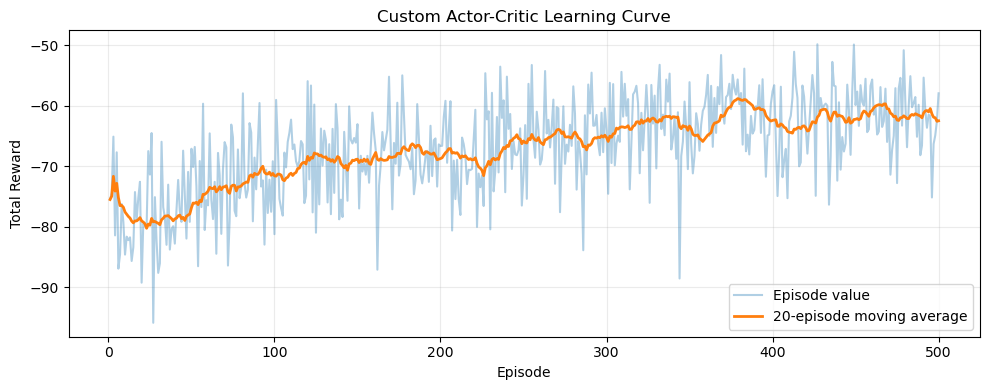

In [140]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.distributions import Categorical
import matplotlib.pyplot as plt
import numpy as np
from stable_baselines3.common.monitor import Monitor

# ============================================================================
# PART 4: ACTOR-CRITIC ON EDGE OFFLOADING ENV (ONE-STEP TD VERSION)
# ============================================================================
print("\n" + "="*60)
print("PART 4: ACTOR-CRITIC ON EDGE OFFLOADING ENV")
print("="*60)

# Khởi tạo lại mô hình và bộ tối ưu hóa
ac_model = ActorCritic(state_dim=4, action_dim=2).to(device)

# Sử dụng LR 1e-3 cho Critic để học hàm giá trị nhanh hơn, Actor dùng 3e-4 để cập nhật mịn
# Tuy nhiên, để đơn giản hóa, ta tối ưu chung với cấu hình Adam mạnh mẽ
ac_optimizer = optim.Adam(ac_model.parameters(), lr=5e-4) 

def train_actor_critic(env_fn, model, optimizer, episodes=500, gamma=0.99):
    model.train()
    rewards_history = []
    
    env = Monitor(env_fn())

    for ep in range(episodes):
        state, _ = env.reset(seed=SEED + ep)
        ep_reward = 0.0

        while True:
            state_t = torch.FloatTensor(state).to(device)
            logits, value = model(state_t)
            
            dist = Categorical(logits=logits)
            action = dist.sample()

            next_state, reward, terminated, truncated, _ = env.step(action.item())
            ep_reward += float(reward)

            # Chuẩn bị tensor cho trạng thái kế tiếp để tính TD Target
            next_state_t = torch.FloatTensor(next_state).to(device)
            _, next_value = model(next_state_t)
            
            # Nếu gặp trạng thái kết thúc, V(next_state) = 0
            done = terminated or truncated
            target_value = reward + (gamma * next_value.detach() * (1 - int(done)))
            
            # --- TÍNH TOÁN LỰC ĐẨY TD ERROR (ADVANTAGE) ---
            td_error = target_value - value
            
            # Lấy log_prob của hành động vừa thực hiện
            log_prob = dist.log_prob(action)
            entropy = dist.entropy()

            # --- TÍNH LOSS NGAY TRONG TỪNG STEP ---
            # critic_loss sử dụng Huber loss (smooth_l1_loss) để chống nhiễu cực đoan từ môi trường
            target_value_reshaped = target_value.view_as(value)
            critic_loss = F.smooth_l1_loss(value, target_value_reshaped)
            
            actor_loss = -(log_prob * td_error.detach()).mean()
            entropy_loss = entropy.mean()

            # Tổng hợp Loss cho từng bước
            loss = actor_loss + 0.5 * critic_loss - 0.01 * entropy_loss

            # Cập nhật trọng số mạng neural ngay lập tức
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            state = next_state
            if done:
                break

        # Lưu lại tổng phần thưởng thực tế của episode đó
        rewards_history.append(ep_reward)

        # In log theo dõi
        if (ep + 1) % 50 == 0:
            avg_rw = np.mean(rewards_history[-50:])
            print(f"Episode {ep+1}/{episodes} | 50-Ep Avg Reward: {avg_rw:.2f}")

    return rewards_history

# Tiến hành huấn luyện
ac_episodes = 500
print(f"Training Custom TD Actor-Critic for {ac_episodes} episodes...")
ac_rewards = train_actor_critic(make_env, ac_model, ac_optimizer, episodes=ac_episodes)

# ----------------------------------------------------------------------------
# ĐỒ THỊ HIỂN THỊ KẾT QUẢ
# ----------------------------------------------------------------------------
print("\nĐang kết xuất biểu đồ kết quả...")
plot_curve(ac_rewards, "Custom Actor-Critic Learning Curve", "Total Reward")
plt.show()

# ============================================================================
# Định nghĩa hàm policy phục vụ khối so sánh ở Part 6
# ============================================================================
def scratch_ac_policy(state, env):
    ac_model.eval()
    with torch.no_grad():
        state_t = torch.FloatTensor(state).to(device)
        logits, _ = ac_model(state_t)
        action = torch.argmax(logits).item()
    return action

---

# PART 5: A2C 


### 6.1 A2C Training and Evaluation



PART 5: A2C (OPTIONAL, STABLE-BASELINES3)
Training SB3 A2C for 10000 timesteps...
SB3 A2C Training complete!


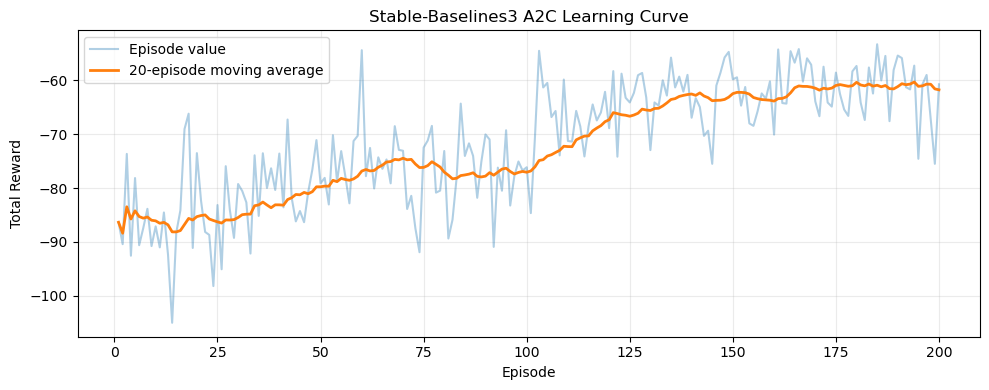

In [141]:
print("\n" + "="*60)
print("PART 5: A2C (OPTIONAL, STABLE-BASELINES3)")
print("="*60)

# ============================================================================
# A2C training and evaluation
# ============================================================================

# ### YOU NEED TO WRITE YOUR CODE BELOW ###

from stable_baselines3 import A2C
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.callbacks import BaseCallback

# 1. Khởi tạo môi trường Vectorized tương thích với cấu trúc Stable-Baselines3
sb3_env = make_vec_env(lambda: make_env(), n_envs=1, seed=SEED)

# Mảng tự định nghĩa để lưu trữ lịch sử phần thưởng của từng Episode
sb3_rewards = []

# --- TỰ ĐỊNH NGHĨA CALLBACK: Cứ mỗi khi kết thúc 1 episode (50 steps) là tự lưu reward ---
class CustomPlotCallback(BaseCallback):
    def __init__(self, verbose=0):
        super(CustomPlotCallback, self).__init__(verbose)
    def _on_step(self) -> bool:
        # Check xem episode hiện tại đã kết thúc chưa (dựa vào thông tin nội bộ của VecEnv)
        if "episode" in self.locals["infos"][0]:
            # Lấy phần thưởng tích lũy (total reward) của episode vừa kết thúc đưa vào mảng
            ep_reward = self.locals["infos"][0]["episode"]["r"]
            sb3_rewards.append(float(ep_reward))
        return True

plot_callback = CustomPlotCallback()

# 2. Định nghĩa tham số mạng Policy tách biệt [128, 128] tương đồng với Part 4
policy_kwargs = dict(net_arch=dict(pi=[128, 128], vf=[128, 128]))

# 3. Khởi tạo tác tử A2C
sb3_model = A2C(
    policy="MlpPolicy",
    env=sb3_env,
    learning_rate=1e-3,
    gamma=0.99,
    policy_kwargs=policy_kwargs,
    seed=SEED,
    verbose=0
)

# 4. Tính toán số timesteps huấn luyện dựa theo trạng thái FAST_MODE
total_timesteps = 10000
print(f"Training SB3 A2C for {total_timesteps} timesteps...")

# Truyền callback tự viết vào hàm học
sb3_model.learn(total_timesteps=total_timesteps, callback=plot_callback)
print("SB3 A2C Training complete!")

# --- THÊM: Vẽ biểu đồ dựa trên mảng tự lưu trữ, không lo bị trống log ---
if len(sb3_rewards) > 0:
    plot_curve(sb3_rewards, title="Stable-Baselines3 A2C Learning Curve", ylabel="Total Reward")
else:
    print("Mảng dữ liệu trống, hãy chắc chắn bạn đã chạy các ô code phía trên!")

# 5. Định nghĩa hàm chính sách của SB3 A2C để truyền xuống khối so sánh
def sb3_a2c_policy(state, env):
    action, _ = sb3_model.predict(state, deterministic=True)
    return int(action)

---

# PART 6: Final Comparison

We compare all methods (baseline policies, Actor-Critic, and A2C) using shared evaluation metrics.

### 7.1 Aggregated Results Table


In [142]:
# ============================================================================
# Build comprehensive comparison table
# ============================================================================

comparison_rows = []

def add_result(method_name, result):
    """Add a result row to the comparison table.
    
    Args:
        method_name: Name of the method
        result: Evaluation result dictionary
    """
    comparison_rows.append({
        'Method': method_name,
        'Avg Latency ↓': result['avg_latency'],
        'P95 Latency ↓': result['p95_latency'],
        'Avg Reward ↑': result['avg_reward'],
        'Gap to Greedy ↓': result['avg_latency'] - baseline_results['Greedy latency']['avg_latency'],
        'Device %': result['device_pct'],
        'Edge %': result['edge_pct'],
    })


### YOU NEED TO WRITE YOUR CODE BELOW ###

# Số lượng episodes dùng để đánh giá cuối cùng
eval_episodes = 500

# Tạo dictionary trung gian bọc kết quả Greedy của Part 3 nhằm tránh lỗi KeyError trong hàm add_result
# Tên khóa phải khớp tuyệt đối với: 'Greedy latency'
greedy_eval = evaluate_edge_policy(make_env, greedy_policy, episodes=eval_episodes)
baseline_results = {'Greedy latency': greedy_eval}

# Tiến hành đánh giá và thêm kết quả của TẤT CẢ các phương pháp vào bảng tổng hợp
print(f"Evaluating all policies over {eval_episodes} episodes to generate comparison table...")

add_result("Random", evaluate_edge_policy(make_env, random_policy, episodes=eval_episodes))
add_result("Device-only", evaluate_edge_policy(make_env, device_policy, episodes=eval_episodes))
add_result("Edge-only", evaluate_edge_policy(make_env, edge_policy, episodes=eval_episodes))
add_result("Greedy latency", greedy_eval)
add_result("Actor-Critic (Scratch)", evaluate_edge_policy(make_env, scratch_ac_policy, episodes=eval_episodes))
add_result("A2C (SB3)", evaluate_edge_policy(make_env, sb3_a2c_policy, episodes=eval_episodes))

# Chuyển đổi list kết quả thành DataFrame và in ra màn hình dạng bảng đẹp mắt
df_comparison = pd.DataFrame(comparison_rows)
print("\n=== FINAL PERFORMANCE COMPARISON ===")
print(df_comparison.to_string(index=False))

Evaluating all policies over 500 episodes to generate comparison table...

=== FINAL PERFORMANCE COMPARISON ===
                Method  Avg Latency ↓  P95 Latency ↓  Avg Reward ↑  Gap to Greedy ↓  Device %  Edge %
                Random    1664.026609    3451.537048    -83.201330       529.985051   0.49640 0.50360
           Device-only    1545.456063    2858.272278    -77.272803       411.414505   1.00000 0.00000
             Edge-only    1771.619343    4611.282251    -88.580967       637.577785   0.00000 1.00000
        Greedy latency    1134.041558    2371.988745    -56.702078         0.000000   0.49252 0.50748
Actor-Critic (Scratch)    1187.789736    2424.920776    -59.389487        53.748178   0.33440 0.66560
             A2C (SB3)    1235.165018    2695.919324    -61.758251       101.123459   0.55260 0.44740


## CONGRATULATIONS TEAM!

Congratulations on Completing Lab 04.2 - Policy-Based Reinforcement Learning for Edge Offloading!

**Key Observations:**

- **REINFORCE** is simple but often has high-variance updates.
- **Actor-Critic** is usually more stable due to TD-based critic guidance.
- **A2C** is a practical implementation of actor-critic methods.
- On EdgeOffloadingEnv, learned policies can approach strong heuristic behavior.
- The task highlights trade-offs between communication latency and compute placement decisions.

**Why This Matters:**

- Edge systems require fast adaptive offloading decisions.
- Policy-based RL provides a data-driven alternative to hand-crafted decision rules.
- These methods form a foundation for many advanced RL algorithms used in networking systems.

References: https://gymnasium.farama.org/ | https://pytorch.org/ | https://stable-baselines3.readthedocs.io/

## ADDITIONAL INFORMATION

**Author**: M.Sc. Phan Trung Phat - Department of Computer Networks and Communications, UIT

**Contact**: phatpt@uit.edu.vn

**Last Updated**: March, 2026